In [2]:
# The path can also be read from a config file, etc.
OPENSLIDE_PATH = r'c:\\openslide-win64\\bin'

import os
if hasattr(os, 'add_dll_directory'):
    # Windows
    with os.add_dll_directory(OPENSLIDE_PATH):
        import openslide
else:
    import openslide
    
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [27]:
def norm_HnE(img, Io=240, alpha=1, beta=0.15):
    
    HERef = np.array([[0.526, 0.2159],
                      [0.2701, 0.8012],
                      [0.4062, 0.5581]])
    
    maxCRef = np.array([1.9705, 1.0308])
    
    h, w, c = img.shape
    
    img = img.reshape((-1,3))
    
    OD = -np.log10((img.astype(np.float64)+1)/Io)
    
    # remove transprent pixels (clear region with no tissue)
    ODhat = OD[~np.any(OD < beta, axis=1)]
    
    eigvals, eigvecs = np.linalg.eigh(np.cov(ODhat.T))
    
    That = ODhat.dot(eigvecs[:,1:3])
    
    phi = np.arctan2(That[:,1], That[:,0])
    
    minPhi = np.percentile(phi, alpha)
    maxPhi = np.percentile(phi, 100 - alpha)
    
    vMin = eigvecs[:,1:3].dot(np.array([(np.cos(minPhi)),np.sin(minPhi)]).T)
    vMax = eigvecs[:,1:3].dot(np.array([(np.cos(maxPhi)),np.sin(maxPhi)]).T)
    
    if vMin[0] > vMax[0]:
        HE = np.array((vMin,vMax)).T
        
    else:
        HE = np.array((vMax,vMin)).T
        
    Y = np.reshape(OD, (-1,3)).T
    
    C = np.linalg.lstsq(HE, Y, rcond=None)[0]
    
    maxC = np.array([np.percentile(C[0,:], 99), np.percentile(C[1,:], 99)])
    tmp = np.divide(maxC, maxCRef)
    C2 = np.divide(C, tmp[:, np.newaxis])
    
    Inorm = np.multiply(Io, np.exp(-HERef.dot(C2)))
    Inorm[Inorm>255] = 254
    Inorm = np.reshape(Inorm.T, (h,w,3)).astype(np.uint8)
    
    H = np.multiply(Io, np.exp(np.expand_dims(-HERef[:,0], axis=1).dot(np.expand_dims(C2[0,:], axis=0))))
    H[H>255] = 254
    H = np.reshape(H.T, (h, w, 3)).astype(np.uint8)
    
    E = np.multiply(Io, np.exp(np.expand_dims(-HERef[:,1], axis=1).dot(np.expand_dims(C2[1,:], axis=0))))
    E[E>255] = 254
    E = np.reshape(E.T, (h, w, 3)).astype(np.uint8)
    
    return (Inorm, H, E) 

### Load images and labels

In [6]:
slide = openslide.open_slide('..\\Data\\BALF\\2019-08-06 11.54.15.ndpi')

In [8]:
slide.dimensions

(28672, 29440)

In [9]:
smaller_region = slide.read_region((16000,16000),0,(1024,1024))

In [11]:
smaller_region_RGB = smaller_region.convert('RGB')

In [13]:
smaller_region_np = np.array(smaller_region_RGB)

In [32]:
norm_img, H_img, E_img = norm_HnE(smaller_region_np, Io=350, alpha=1, beta=0.15)

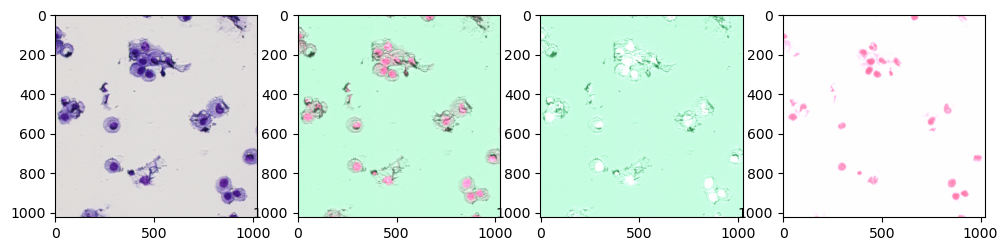

In [33]:
fig, ax = plt.subplots(1,4,figsize=(12,12))

ax[0].imshow(smaller_region_np)
ax[1].imshow(norm_img)
ax[2].imshow(H_img)
ax[3].imshow(E_img)